In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")


In [5]:
soh_df = pd.read_csv("processed_data/soh.csv")
soh_df.head()


,cycle_id,capacity_ah,SOH
0,1,1.705987,1.000000
1,3,1.540807,0.903176
2,5,1.548591,0.907739
3,6,1.537045,0.900971
4,7,1.532369,0.898230


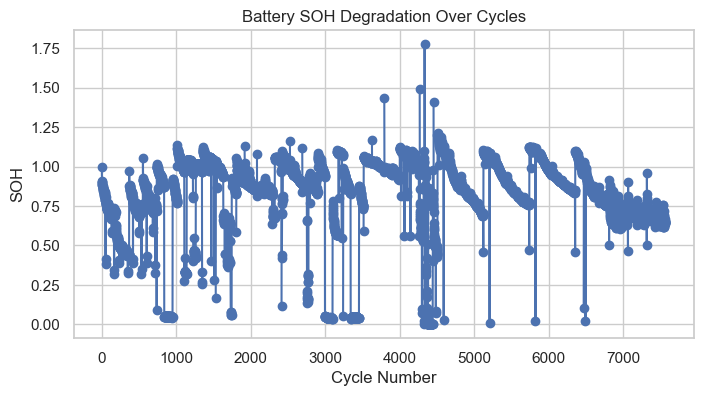

In [6]:
plt.figure(figsize=(8,4))
plt.plot(soh_df["cycle_id"], soh_df["SOH"], marker='o')
plt.xlabel("Cycle Number")
plt.ylabel("SOH")
plt.title("Battery SOH Degradation Over Cycles")
plt.show()


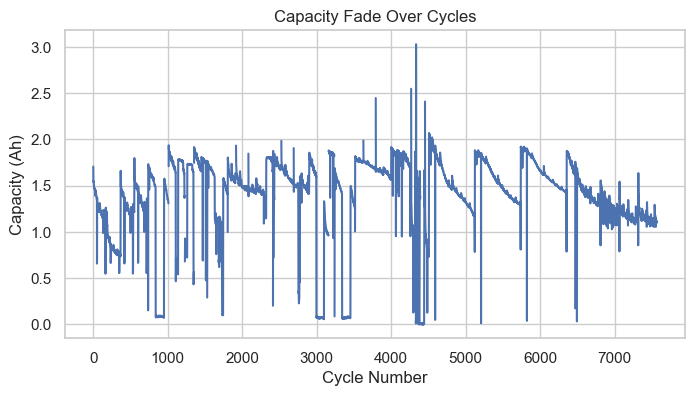

In [7]:
plt.figure(figsize=(8,4))
plt.plot(soh_df["cycle_id"], soh_df["capacity_ah"])
plt.xlabel("Cycle Number")
plt.ylabel("Capacity (Ah)")
plt.title("Capacity Fade Over Cycles")
plt.show()


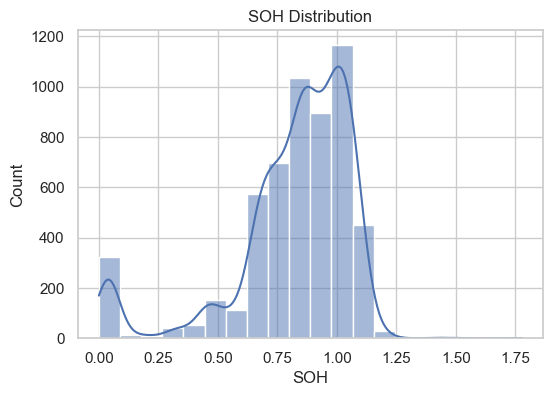

In [8]:
plt.figure(figsize=(6,4))
sns.histplot(soh_df["SOH"], bins=20, kde=True)
plt.title("SOH Distribution")
plt.show()


In [9]:
df = pd.read_csv("processed_data/cycles/cycle_00001.csv")
df.head()


,Voltage_measured,Current_measured,Temperature_measured,Current_load,Voltage_load,Time,SOC,cycle_id
0,4.246711,0.000252,6.212696,0.0002,0.000,0.000,1.000000,/Users/lubhanamutha/Desktop/BMS/cleaned_datase...
1,4.246764,-0.001411,6.234019,0.0002,4.262,9.360,0.999998,/Users/lubhanamutha/Desktop/BMS/cleaned_datase...
2,4.039277,-0.995093,6.250255,1.0000,3.465,23.281,0.998074,/Users/lubhanamutha/Desktop/BMS/cleaned_datase...
3,4.019506,-0.996731,6.302176,1.0000,3.451,36.406,0.996257,/Users/lubhanamutha/Desktop/BMS/cleaned_datase...
4,4.004763,-0.992845,6.361645,1.0000,3.438,49.625,0.994434,/Users/lubhanamutha/Desktop/BMS/cleaned_datase...


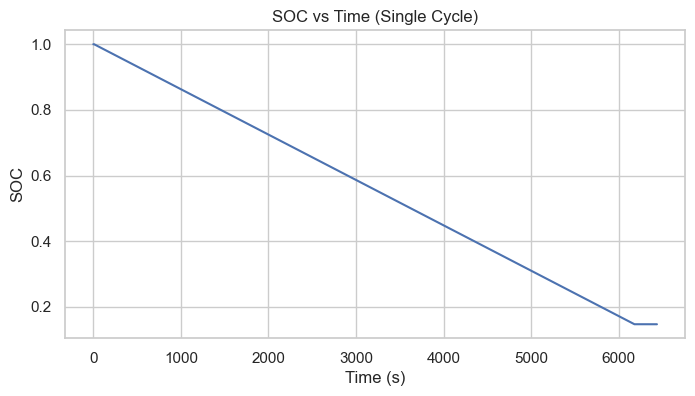

In [10]:
plt.figure(figsize=(8,4))
plt.plot(df["Time"], df["SOC"])
plt.xlabel("Time (s)")
plt.ylabel("SOC")
plt.title("SOC vs Time (Single Cycle)")
plt.show()


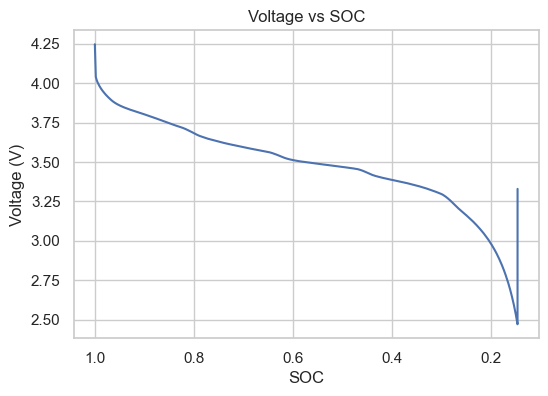

In [11]:
plt.figure(figsize=(6,4))
plt.plot(df["SOC"], df["Voltage_measured"])
plt.xlabel("SOC")
plt.ylabel("Voltage (V)")
plt.title("Voltage vs SOC")
plt.gca().invert_xaxis()
plt.show()


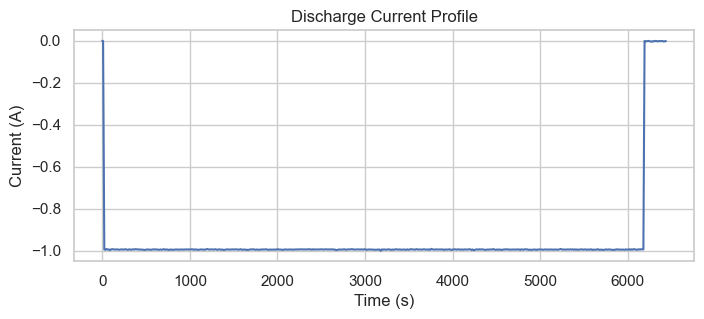

In [12]:
plt.figure(figsize=(8,3))
plt.plot(df["Time"], df["Current_measured"])
plt.xlabel("Time (s)")
plt.ylabel("Current (A)")
plt.title("Discharge Current Profile")
plt.show()


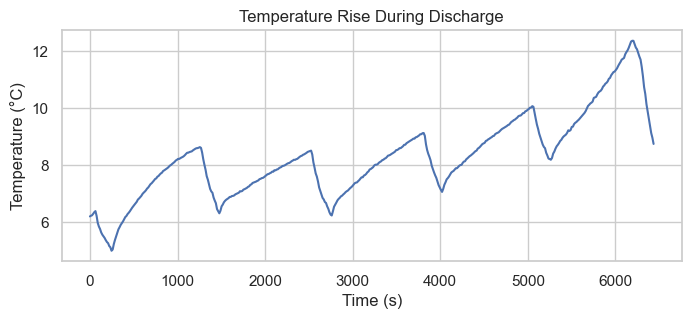

In [13]:
plt.figure(figsize=(8,3))
plt.plot(df["Time"], df["Temperature_measured"])
plt.xlabel("Time (s)")
plt.ylabel("Temperature (°C)")
plt.title("Temperature Rise During Discharge")
plt.show()


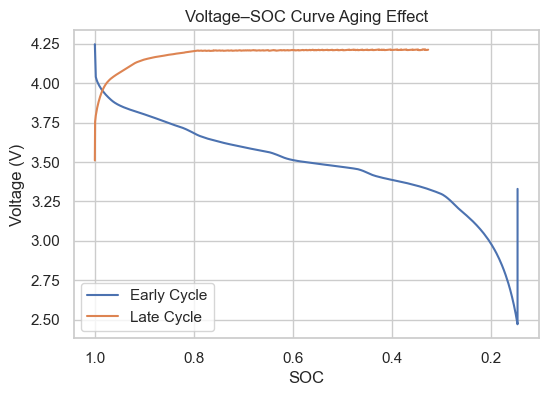

In [15]:
df_early = pd.read_csv("processed_data/cycles/cycle_00001.csv")
df_late  = pd.read_csv("processed_data/cycles/cycle_00050.csv")  # adjust if needed

plt.figure(figsize=(6,4))
plt.plot(df_early["SOC"], df_early["Voltage_measured"], label="Early Cycle")
plt.plot(df_late["SOC"], df_late["Voltage_measured"], label="Late Cycle")
plt.xlabel("SOC")
plt.ylabel("Voltage (V)")
plt.title("Voltage–SOC Curve Aging Effect")
plt.legend()
plt.gca().invert_xaxis()
plt.show()


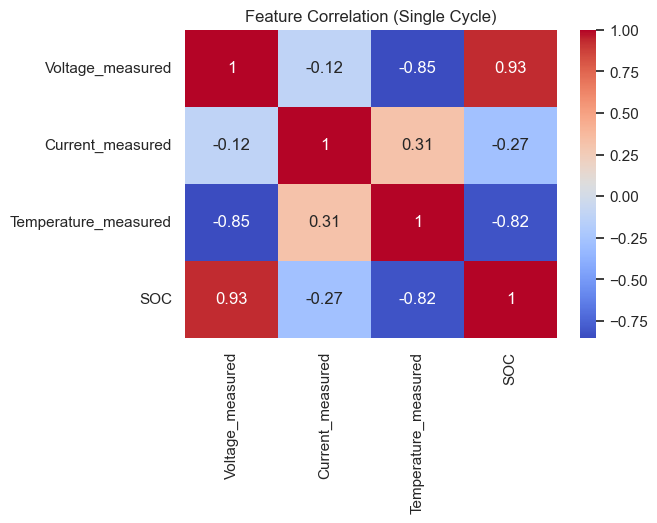

In [16]:
features = [
    "Voltage_measured",
    "Current_measured",
    "Temperature_measured",
    "SOC"
]

corr = df[features].corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Feature Correlation (Single Cycle)")
plt.show()
